## Autoencoders Lab
#### Visualizing HapMap phase 3 populations

**This is a solution template. Every chunk of code requiring your input will begin with the # TASK comment and all places where you should fill-in with your code are marked by ellipsis (...).**

### Stage 0 - getting the data

First, we will download the data from the linked Dropbox account. The code is hidden as it is not super important here. Double-click below if you are curious to see it!



In [276]:
# @title Load raw data. Double click to see the code. { display-mode: "form" }

# !wget https://www.dropbox.com/s/g7862q1l4ls9z3x/autosomal_5k_matrix.csv
# !wget https://www.dropbox.com/s/3lv0062dw20qdqg/autosomal_5k_phenos.csv
# !wget https://www.dropbox.com/s/6nzrusxkm536a5j/autosomal_5k_kinship.csv

Now, we will load the data and make sure they look as expected. Note, the genotypes per individual (row) are encoded as the count of minor alleles and thus can take values `gt = {0, 1, 2}`.

In [277]:
import numpy as np
import pandas as pd
import tensorflow as tf
import seaborn as sns
from tensorflow import keras
from tensorflow.keras import layers
from matplotlib import pyplot as plt

data = pd.read_csv("../datasets/genomics/autosomal_5k_matrix.csv", header=0, index_col=0)
pheno = pd.read_csv("../datasets/genomics/autosomal_5k_phenos.csv", header=0, index_col=0)

data.head()

,rs416967,rs17013842,rs13052452,rs11049986,rs10994341,rs1504289,rs882529,rs3885937,rs537330,rs9372090,...,rs1558766,rs7818288,rs1051685,rs11223492,rs789492,rs6557516,rs7313246,rs317892,rs11937009,rs2806497
NA19919,2,1,0,1,1,0,0,1,1,1,...,0,1,0,0,1,0,1,1,1,0
NA19916,1,0,0,1,1,0,1,1,2,1,...,0,0,0,0,0,1,1,1,1,0
NA19835,0,0,1,1,0,1,0,2,2,1,...,0,1,0,0,0,0,2,2,0,0
NA20282,1,1,0,1,0,0,0,0,1,1,...,0,0,0,0,0,0,1,2,0,0
NA19703,0,0,0,0,1,1,0,0,0,2,...,0,1,1,0,1,1,1,1,2,0


In [278]:
pheno.head()

,id,sex,FID,dad,mom,pheno,population
NA19919,NA19919,1,2427,NA19908,NA19909,0,ASW
NA19916,NA19916,1,2431,0,0,0,ASW
NA19835,NA19835,0,2424,0,0,0,ASW
NA20282,NA20282,0,2469,0,0,0,ASW
NA19703,NA19703,1,2368,0,0,0,ASW


Now, we will create a dictionary and re-name our populations so that the names are a bit more informative:

In [279]:
pop_dict = {'ASW':'African ancestry in SW USA',
            'CEU':'Utah residents with N and W European ancestry',
            'CHB':'Han Chinese in Beijing China',
            'CHD':'Chinese in Metropolitan Denver Colorado',
            'GIH':'Gujarati Indians in Houston Texas',
            'JPT':'Japanese in Tokyo Japan',
            'LWK':'Luhya in Webuye Kenya',
            'MEX':'Mexican ancestry in Los Angeles California',
            'MKK':'Maasai in Kinyawa Kenya',
            'TSI':'Toscans in Italy',
            'YRI':'Yoruba in Ibadan Nigeria'}
pheno2 = pheno.replace({"population": pop_dict})
pheno2.head()

,id,sex,FID,dad,mom,pheno,population
NA19919,NA19919,1,2427,NA19908,NA19909,0,African ancestry in SW USA
NA19916,NA19916,1,2431,0,0,0,African ancestry in SW USA
NA19835,NA19835,0,2424,0,0,0,African ancestry in SW USA
NA20282,NA20282,0,2469,0,0,0,African ancestry in SW USA
NA19703,NA19703,1,2368,0,0,0,African ancestry in SW USA


In [280]:
N_people = pheno2.shape[0]
N_males = np.count_nonzero(pheno2['sex'] == 0) # Assuming 0 is male and 1 is female
N_females = np.count_nonzero(pheno2['sex'] == 1)
N_families = np.unique(pheno2['FID']).shape[0]

print(f'Number of individuals = {N_people}')
print(f'{N_males/N_people*100:.1f}% are males and {N_females/N_people*100:.1f}% are females')
print(f'Number of families = {N_families}')

Number of individuals = 1184
50.3% are males and 49.7% are females
Number of families = 770


From the 1184 individuals, there are 770 different families. Males and females are almost equally represented in the analyzed population.

In [281]:
# data_parents = pheno2[(pheno2['dad'] != '0') & (pheno2['mom'] != '0')][['dad', 'mom']]
data_dads = pheno2[pheno2['dad'] != '0'][['dad']]
data_moms = pheno2[pheno2['mom'] != '0'][['mom']]

# Half siblings sharing dad
dad_siblings = 0
for dad in data_dads['dad']:
    s = np.count_nonzero(data_dads['dad'] == dad)
    if s > 1:
        dad_siblings += 1
print('Half-siblings sharing dad:', dad_siblings)

# Half siblings sharing mom
mom_siblings = 0
for mom in data_moms['mom']:
    s = np.count_nonzero(data_moms['mom'] == mom)
    if s > 1:
        mom_siblings += 1
print('Half-siblings sharing mom:', mom_siblings)

Half-siblings sharing dad: 0
Half-siblings sharing mom: 0


With the parent data we have, there is no siblings at all.

In [282]:
for pop in pop_dict.values():
    print(pop)
    mask = pheno2['population'] == pop
    print(f'\tNumber of individuals = {np.count_nonzero(mask)}')
    print(f'\t{np.count_nonzero(pheno2[mask]['sex'] == 0)/np.count_nonzero(mask)*100:.1f}% are males',
          f'and {np.count_nonzero(pheno2[mask]['sex'] == 1)/np.count_nonzero(mask)*100:.1f}% are females')

African ancestry in SW USA
	Number of individuals = 83
	54.2% are males and 45.8% are females
Utah residents with N and W European ancestry
	Number of individuals = 165
	51.5% are males and 48.5% are females
Han Chinese in Beijing China
	Number of individuals = 84
	50.0% are males and 50.0% are females
Chinese in Metropolitan Denver Colorado
	Number of individuals = 85
	51.8% are males and 48.2% are females
Gujarati Indians in Houston Texas
	Number of individuals = 88
	48.9% are males and 51.1% are females
Japanese in Tokyo Japan
	Number of individuals = 86
	48.8% are males and 51.2% are females
Luhya in Webuye Kenya
	Number of individuals = 90
	50.0% are males and 50.0% are females
Mexican ancestry in Los Angeles California
	Number of individuals = 77
	55.8% are males and 44.2% are females
Maasai in Kinyawa Kenya
	Number of individuals = 171
	49.7% are males and 50.3% are females
Toscans in Italy
	Number of individuals = 88
	50.0% are males and 50.0% are females
Yoruba in Ibadan Niger

In general, all populations have the same amount of males and females.

We scale the genotypes that take the values 0, 1, 2 by dividing by 2.

In [283]:
# TASK Scaling
# We need to scale our counts data so that it is bound between 0 and 1.

geno_data = data/2
geno_data.head()

,rs416967,rs17013842,rs13052452,rs11049986,rs10994341,rs1504289,rs882529,rs3885937,rs537330,rs9372090,...,rs1558766,rs7818288,rs1051685,rs11223492,rs789492,rs6557516,rs7313246,rs317892,rs11937009,rs2806497
NA19919,1.0,0.5,0.0,0.5,0.5,0.0,0.0,0.5,0.5,0.5,...,0.0,0.5,0.0,0.0,0.5,0.0,0.5,0.5,0.5,0.0
NA19916,0.5,0.0,0.0,0.5,0.5,0.0,0.5,0.5,1.0,0.5,...,0.0,0.0,0.0,0.0,0.0,0.5,0.5,0.5,0.5,0.0
NA19835,0.0,0.0,0.5,0.5,0.0,0.5,0.0,1.0,1.0,0.5,...,0.0,0.5,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
NA20282,0.5,0.5,0.0,0.5,0.0,0.0,0.0,0.0,0.5,0.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.5,1.0,0.0,0.0
NA19703,0.0,0.0,0.0,0.0,0.5,0.5,0.0,0.0,0.0,1.0,...,0.0,0.5,0.5,0.0,0.5,0.5,0.5,0.5,1.0,0.0


In [284]:
# TASK Randomly split into the training and the validation set, so that 80 per-cent of individuals ends up in the training set.
train = geno_data.sample(frac = 0.8, random_state = 42)
test = geno_data.drop(train.index)
train = train.copy()
test = test.copy()
train.reset_index()
test.reset_index()

# TASK Print some info about the resulting split
print("Total number of individuals:", geno_data.shape[0])
print("\t - training set:", train.shape[0])
print("\t - test set:", test.shape[0])

Total number of individuals: 1184
	 - training set: 947
	 - test set: 237


### Comparing first autoencoder to PCA and MDS

In [285]:
# TASK Specify the autoencoder model
train_tensor = train.to_numpy()
print(type(train_tensor))

# TASK Hyperparameters
# use ReLu activations, ADAM optimizer and
# mean squared error as the loss function
hp_loss_fn = 'mse'
hp_act_fn = 'relu'
hp_optimizer = 'adam'
hp_metrics = ['mse','mae','mape']

input_data = keras.Input(shape = (train_tensor.shape[1],))

# TASK Define architecture of the encoder:
# the second layer should be a batch normalization
def Encoder(input):
  # Encoder
  layer1 = layers.Dense(units = 1500, activation = hp_act_fn, name='layer1')(input)
  layer2 = layers.BatchNormalization(name='layer2')(layer1)
  layer3 = layers.Dropout(rate = 0.025, name='layer3')(layer2)
  layer4 = layers.Dense(units = 250, activation = hp_act_fn, name='layer4')(layer3)
  layer5 = layers.Dropout(rate = 0.025, name='layer5')(layer4)
  layer6 = layers.Dense(units = 25, activation = hp_act_fn, name='layer6')(layer5)
  bottleneck = layers.Dense(units = 2, name='layer_bottleneck')(layer6)
  return(bottleneck)

# TASK Look at the encoder, complete the decoder function
def Decoder(bottleneck):
  # Decoder
  layer7 = layers.Dense(units = 25, activation = hp_act_fn, name='layer7')(bottleneck)
  layer8 = layers.Dropout(rate = 0.025, name='layer8')(layer7)
  layer9 = layers.Dense(units = 250, activation = hp_act_fn, name='layer9')(layer8)
  layer10 = layers.Dropout(rate = 0.025, name='layer10') (layer9)
  layer11 = layers.Dense(units = 1500, activation = hp_act_fn, name='layer11')(layer10)
  layer12 = layers.Dense(units = train_tensor.shape[1], activation = 'sigmoid', name='layer_output')(layer11)
  return(layer12)

def Autoencoder(input):
  enc = Encoder(input)
  autoenc = Decoder(enc)
  return(autoenc)

autoencoder_model = keras.Model(inputs = input_data, outputs = Autoencoder(input_data))
autoencoder_model.compile(
  loss = hp_loss_fn,
  optimizer = hp_optimizer,
  metrics = hp_metrics
)

# TASK Visualise the created architecture and summarise its parameters
autoencoder_model.summary()

<class 'numpy.ndarray'>


Model: "functional_55"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_35 (InputLayer)     │ (None, 5000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer1 (Dense)                  │ (None, 1500)           │     7,501,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (BatchNormalization)     │ (None, 1500)           │         6,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer3 (Dropout)                │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer4 (Dense)                  │ (None, 250)            │       375,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer5 (Dropout)                │ (None, 250)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer6 (Dense)                  │ (None, 25)             │         6,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_bottleneck (Dense)        │ (None, 2)              │            52 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer7 (Dense)                  │ (None, 25)             │            75 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer8 (Dropout)                │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer9 (Dense)                  │ (None, 250)            │         6,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer10 (Dropout)               │ (None, 250)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer11 (Dense)                 │ (None, 1500)           │       376,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_output (Dense)            │ (None, 5000)           │     7,505,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,777,152 (60.19 MB)

 Trainable params: 15,774,152 (60.17 MB)

 Non-trainable params: 3,000 (11.72 KB)

In [286]:
# TASK Set hyperparameters for model fitting
# Begin by training for 30 epochs, with mini-batch of 256 and validation set
# having 20 per-cent of examples
hp_epochs = 30
hp_batch_size = 256
hp_val_split = 0.2

autoencoder = autoencoder_model.fit(x = train_tensor,
                      y = train_tensor,
                      epochs = hp_epochs,
                      batch_size = hp_batch_size,
                      shuffle = True,
                      validation_split = hp_val_split,
                      )

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - loss: 0.1841 - mae: 0.3701 - mape: 340226848.0000 - mse: 0.1841 - val_loss: 0.1823 - val_mae: 0.3678 - val_mape: 338149824.0000 - val_mse: 0.1823
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.1585 - mae: 0.3487 - mape: 308686368.0000 - mse: 0.1585 - val_loss: 0.1411 - val_mae: 0.3347 - val_mape: 288576896.0000 - val_mse: 0.1411
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 0.0864 - mae: 0.2265 - mape: 120641064.0000 - mse: 0.0864 - val_loss: 0.0719 - val_mae: 0.1988 - val_mape: 94174352.0000 - val_mse: 0.0719
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0805 - mae: 0.1669 - mape: 44363596.0000 - mse: 0.0805 - val_loss: 0.0754 - val_mae: 0.1719 - val_mape: 72108536.0000 - val_mse: 0.0754
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.0771 - mae: 0.1653 - mape: 57623708.0000 - mse: 0.0771 - val_loss: 0.0743 - val_mae: 0.1742 - val_mape: 72662032.0000 - val_mse: 0.0743
Epoch 6/30
3/3 ━━

Now, let us look at the training process:

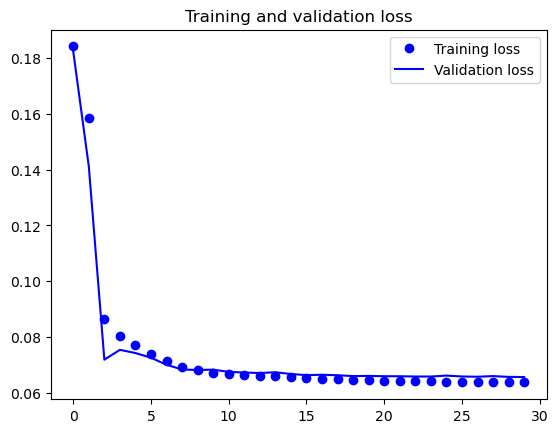

In [287]:
loss = autoencoder.history['loss']
val_loss = autoencoder.history['val_loss']
epochs = range(hp_epochs)
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

Now, that the model is trained, we can save the weights and use them to build an encoder. Note that weights are saved for the entire autoencoder, so we need to use `skip_mismatch = True` along with `by_name = True` to initialize weights in our encoder.

In [288]:
autoencoder_model.save_weights('checkpoints/ex9/autoencoder_weights.weights.h5',
                               overwrite = True)

encoder_model = keras.Model(inputs = input_data, outputs = Encoder(input_data))
encoder_model.load_weights('checkpoints/ex9/autoencoder_weights.weights.h5',
                           skip_mismatch = True)
encoder_model.compile(
  loss = hp_loss_fn,
  optimizer = hp_optimizer,
  metrics = hp_metrics,
)

Let us embed our genotyping data using the encoder we have just constructed.
We can also visualise the embedding.

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


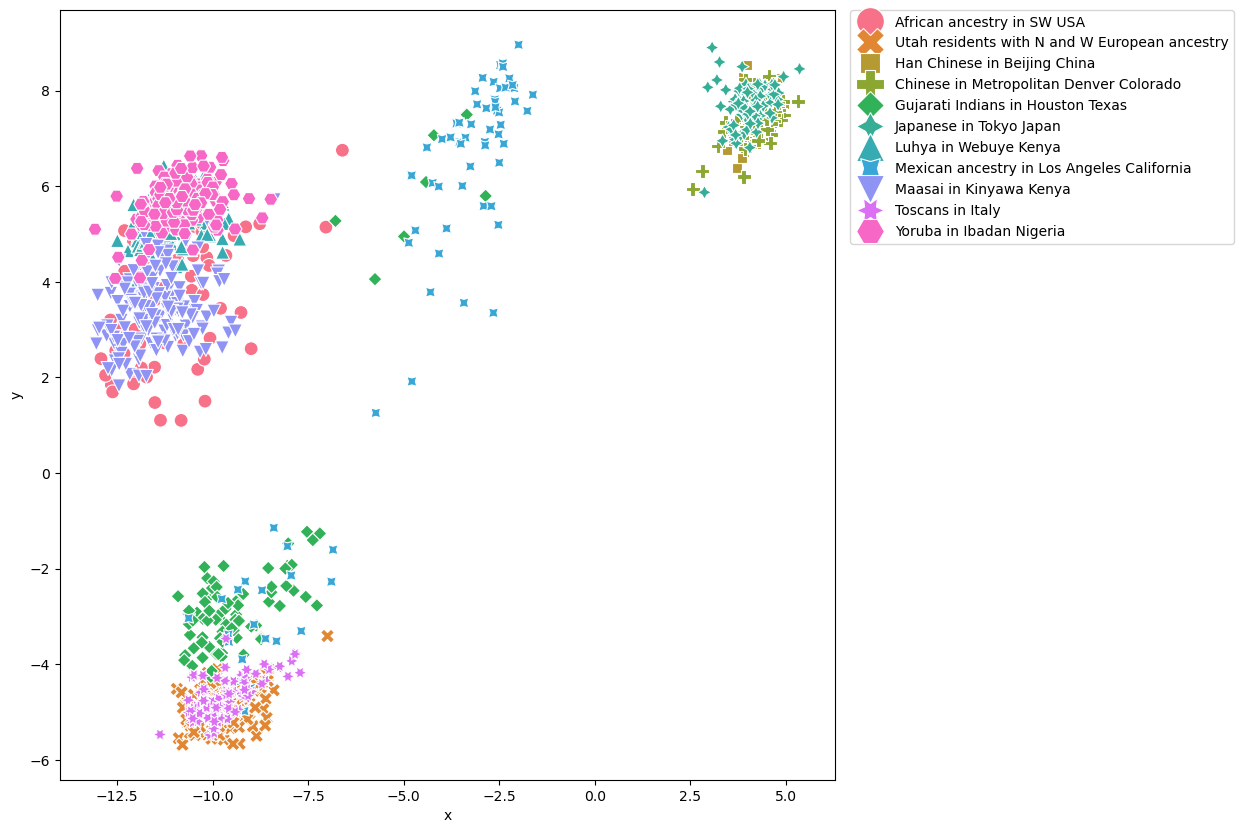

In [289]:
embeded_points = encoder_model.predict(geno_data.to_numpy())
# print(embeded_points)

x = embeded_points[:,0]
y = embeded_points[:,1]
pop = pheno2['population']
data = {'x':x, 'y':y, 'pop':pop}
plt.figure(figsize = (10,10))
sns.scatterplot(x='x', y='y', data=data, hue='pop', style='pop', s=100)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, markerscale=2)
plt.show()

Now, we will compare the result with:
* MDS on the kinship matrix
* PCA perfored directly on raw genotypes


In [290]:
kinship = pd.read_csv("../datasets/genomics/autosomal_5k_kinship.csv", header=0, index_col=0)

In [291]:
from sklearn.manifold import MDS
embedding = MDS(n_components=2)
mds_embedding = embedding.fit_transform(kinship)

/home/juan-prado/miniforge3/envs/tensorflow/lib/python3.12/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/home/juan-prado/miniforge3/envs/tensorflow/lib/python3.12/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/home/juan-prado/miniforge3/envs/tensorflow/lib/python3.12/site-packages/sklearn/manifold/_mds.py:794: UserWarning: The provided input is a square matrix. Note that ``fit`` constructs a dissimilarity matrix from data and will treat rows as samples and columns as features. To use a pre-computed dissimilarity matrix, set ``metric='precomputed'``.
  warnings.warn(


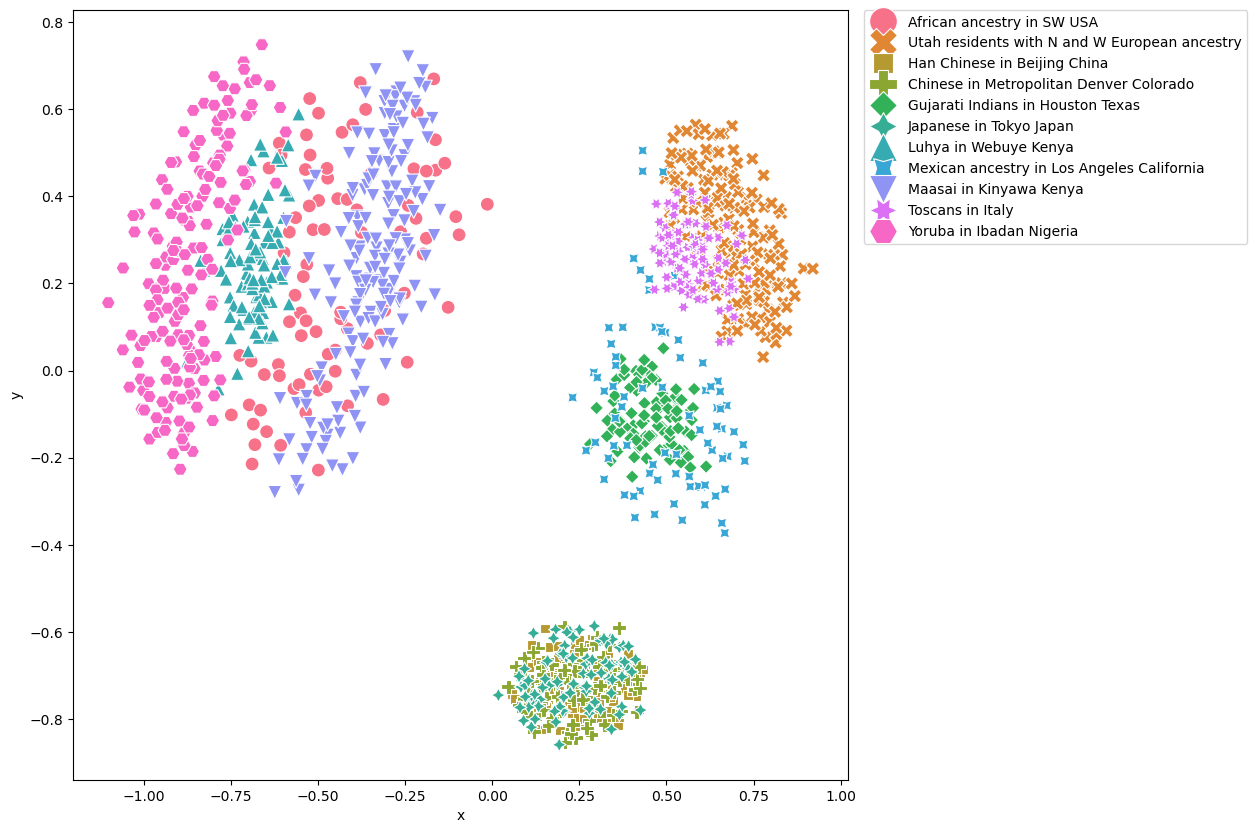

In [292]:
# TASK Plot MDS embedding in a way similar to plotting autoencoder embeddings
x = mds_embedding[:,0]
y = mds_embedding[:,1]
data = {'x':x, 'y':y, 'pop':pop}
plt.figure(figsize = (10,10))
sns.scatterplot(x='x', y='y', data=data, hue='pop', style='pop', s=100)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, markerscale=2)
plt.show()

Finally, we will perform PCA on raw genotypes:

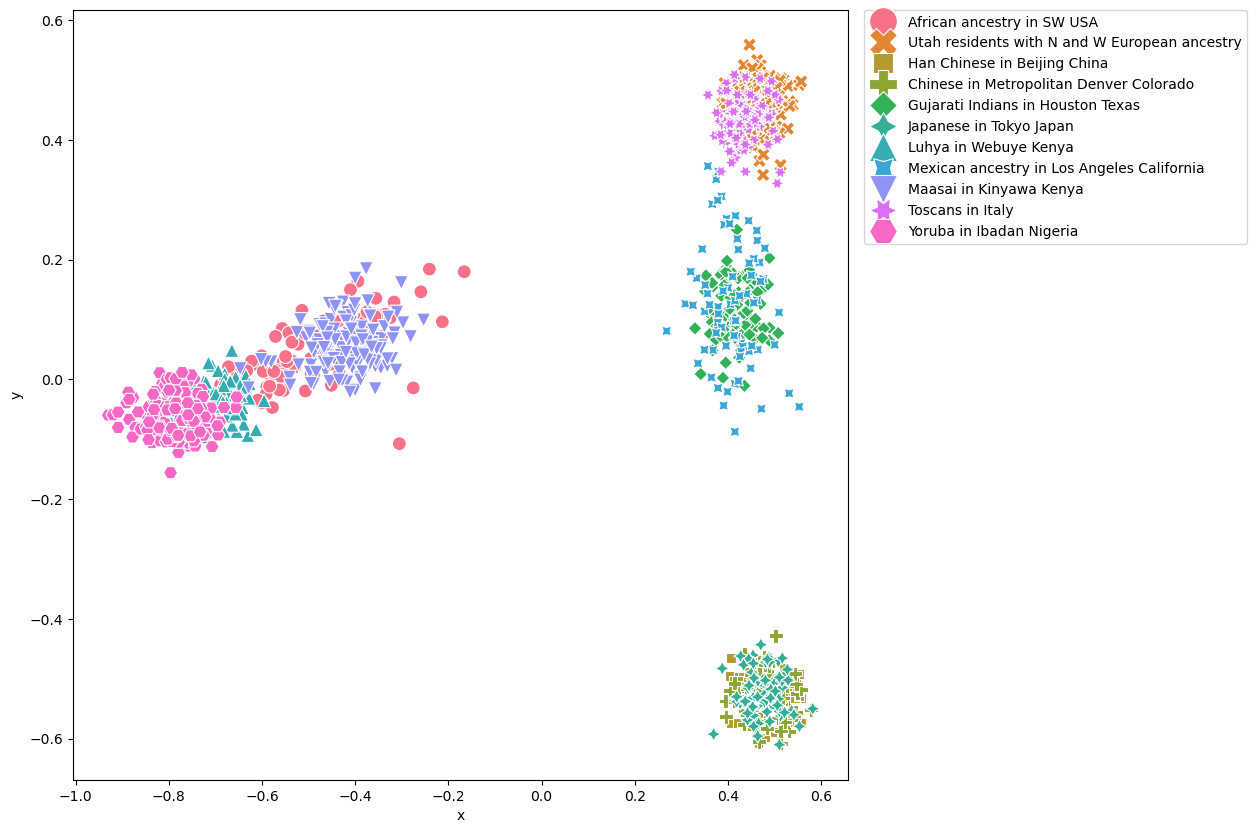

In [293]:
# TASK perform PCA with 2 components on raw genotypes (use geno_data as input but remember it has been scaled)
# Visualise the result.
from sklearn.decomposition import PCA
embedding = PCA(n_components=2)
pca_embedding = embedding.fit_transform(kinship)

x = pca_embedding[:,0]
y = pca_embedding[:,1]
data = {'x':x, 'y':y, 'pop':pop}
plt.figure(figsize = (10,10))
sns.scatterplot(x='x', y='y', data=data, hue='pop', style='pop', s=100)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, markerscale=2)
plt.show()

For now, we see that the 3 methods are grouping the populations in the same 4 different groups:
- Africans: African ancestry in SW USA, Luhya in Webuye Kenya, Maasai in Kinyawa Kenya, Yoruba in Ibadan Nigeria
- Europeans: Utah residents with N and W European ancestry, Toscans in Italy
- North americans: Mexican ancestry in Los Angeles California, Gujarati Indians in Houston Texas
- Asiatics: Han Chinese in Beijing China, Chinese in Metropolitan Denver Colorado, Japanese in Tokyo Japan

The outliers in the autoencoder are mixing with other groups.
PCA has the most compact and separated groups.

### Trying different architectures

Let us try a different architecture for the autoencoder.

Since the training time was rather low, we first will try with a larger number of hidden layers.

In [294]:
# TASK Hyperparameters
# use ReLu activations, ADAM optimizer and
# mean squared error as the loss function
hp_loss_fn = 'mse'
hp_act_fn = 'relu'
hp_optimizer = 'adam'
hp_metrics = ['mse','mae','mape']

input_data = keras.Input(shape = (train_tensor.shape[1],))

# TASK Define architecture of the encoder:
# the second layer should be a batch normalization
def Encoder(input):
  # Encoder
  x = layers.Dense(units = 1500, activation = hp_act_fn)(input)
  x = layers.BatchNormalization()(x)
  x = layers.Dropout(rate = 0.025)(x)
  x = layers.Dense(units = 600, activation = hp_act_fn)(x)
  x = layers.Dropout(rate = 0.025)(x)
  x = layers.Dense(units = 250, activation = hp_act_fn)(x)
  x = layers.Dropout(rate = 0.025)(x)
  x = layers.Dense(units = 25, activation = hp_act_fn)(x)
  bottleneck = layers.Dense(units = 2)(x)
  return(bottleneck)

# TASK Look at the encoder, complete the decoder function
def Decoder(bottleneck):
  # Decoder
  x = layers.Dense(units = 25, activation = hp_act_fn)(bottleneck)
  x = layers.Dropout(rate = 0.025)(x)
  x = layers.Dense(units = 250, activation = hp_act_fn)(x)
  x = layers.Dropout(rate = 0.025) (x)
  x = layers.Dense(units = 600, activation = hp_act_fn)(x)
  x = layers.Dropout(rate = 0.025) (x)
  x = layers.Dense(units = 1500, activation = hp_act_fn)(x)
  output = layers.Dense(units = train_tensor.shape[1], activation = 'sigmoid')(x)
  return(output)

def Autoencoder(input):
  enc = Encoder(input)
  autoenc = Decoder(enc)
  return(autoenc)

autoencoder_model = keras.Model(inputs = input_data, outputs = Autoencoder(input_data))
autoencoder_model.compile(
  loss = hp_loss_fn,
  optimizer = hp_optimizer,
  metrics = hp_metrics
)

In [295]:
# TASK Set hyperparameters for model fitting
# Begin by training for 30 epochs, with mini-batch of 256 and validation set
# having 20 per-cent of examples
hp_epochs = 30
hp_batch_size = 256
hp_val_split = 0.2

autoencoder = autoencoder_model.fit(x = train_tensor,
                      y = train_tensor,
                      epochs = hp_epochs,
                      batch_size = hp_batch_size,
                      shuffle = True,
                      validation_split = hp_val_split,
                      )

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 238ms/step - loss: 0.1839 - mae: 0.3699 - mape: 339988096.0000 - mse: 0.1839 - val_loss: 0.1800 - val_mae: 0.3663 - val_mape: 335694720.0000 - val_mse: 0.1800
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 0.1364 - mae: 0.3242 - mape: 269481792.0000 - mse: 0.1364 - val_loss: 0.0853 - val_mae: 0.2621 - val_mape: 177680560.0000 - val_mse: 0.0853
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - loss: 0.0858 - mae: 0.1764 - mape: 39057704.0000 - mse: 0.0858 - val_loss: 0.0759 - val_mae: 0.1736 - val_mape: 71388912.0000 - val_mse: 0.0759
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 0.0819 - mae: 0.1675 - mape: 56155672.0000 - mse: 0.0819 - val_loss: 0.0746 - val_mae: 0.1752 - val_mape: 78192648.0000 - val_mse: 0.0746
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - loss: 0.0765 - mae: 0.1794 - mape: 73828536.0000 - mse: 0.0765 - val_loss: 0.0722 - val_mae: 0.1779 - val_mape: 79515176.0000 - val_mse: 0.0722
Epoch 6/30
3/3 ━

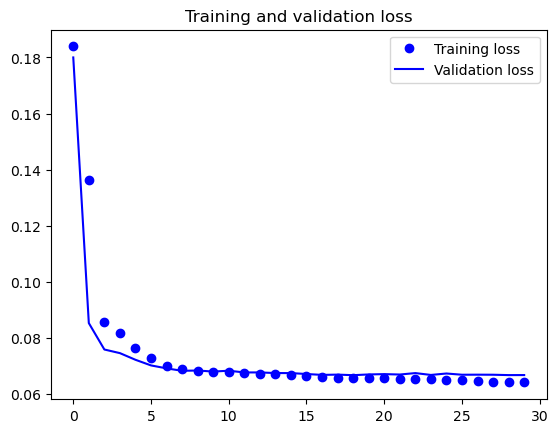

In [296]:
loss = autoencoder.history['loss']
val_loss = autoencoder.history['val_loss']
epochs = range(hp_epochs)
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

In [297]:
autoencoder_model.save_weights('checkpoints/ex9/autoencoder1_weights.weights.h5',
                               overwrite = True)

encoder_model = keras.Model(inputs = input_data, outputs = Encoder(input_data))
encoder_model.load_weights('checkpoints/ex9/autoencoder1_weights.weights.h5',
                           skip_mismatch = True)
encoder_model.compile(
  loss = hp_loss_fn,
  optimizer = hp_optimizer,
  metrics = hp_metrics,
)

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


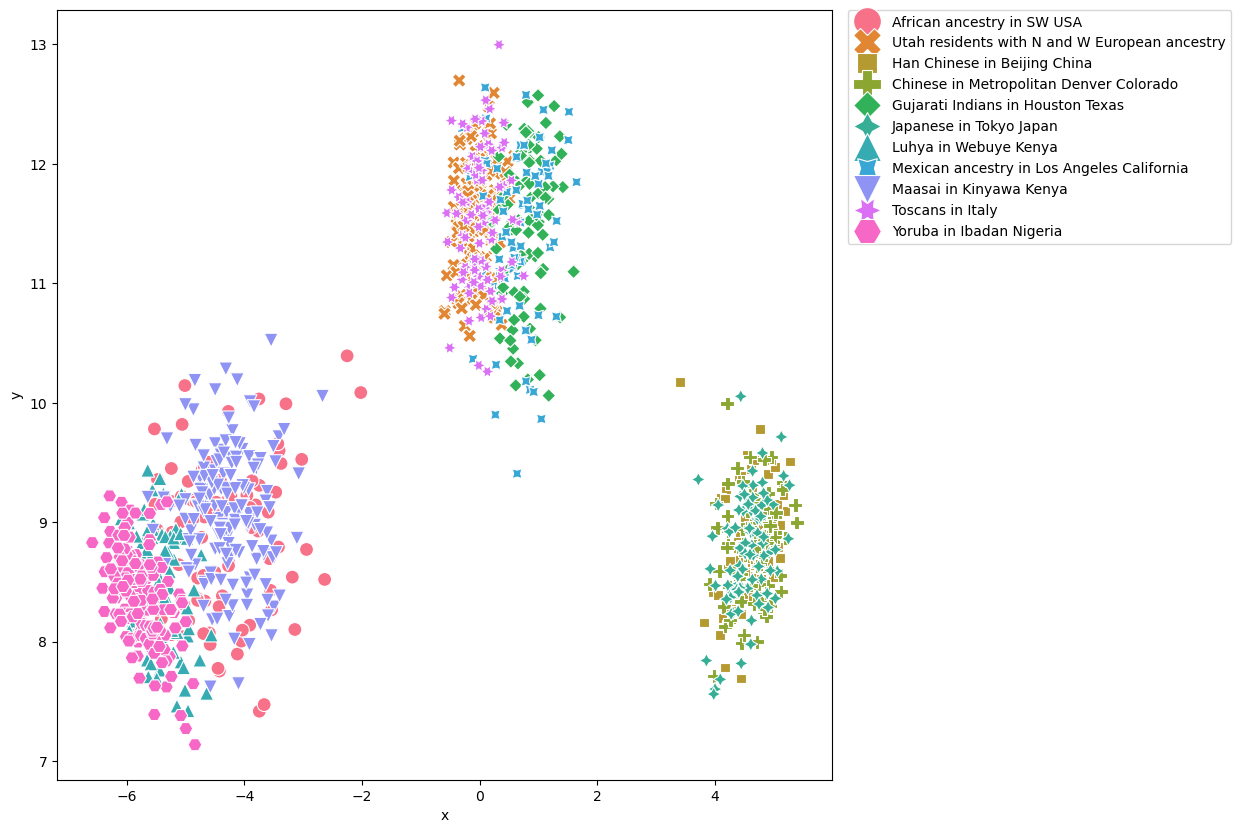

In [298]:
embeded_points = encoder_model.predict(geno_data.to_numpy())
# print(embeded_points)

x = embeded_points[:,0]
y = embeded_points[:,1]
pop = pheno2['population']
data = {'x':x, 'y':y, 'pop':pop}
plt.figure(figsize = (10,10))
sns.scatterplot(x='x', y='y', data=data, hue='pop', style='pop', s=100)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, markerscale=2)
plt.show()

This choice does not improve significantly the performance. Actually, it is a bit worse, with only 3 clear groups now.

We go back to the initial architecture. Let us try then to tune the hyperparameters and get a better performance. We will use a smaller batch size (32) and train over more epochs (50).

In [299]:
# use ReLu activations, ADAM optimizer and
# mean squared error as the loss function
hp_loss_fn = 'mse'
hp_act_fn = 'relu'
hp_optimizer = 'adam'
hp_metrics = ['mse','mae','mape']

input_data = keras.Input(shape = (train_tensor.shape[1],))

# TASK Define architecture of the encoder:
# the second layer should be a batch normalization
def Encoder(input):
  # Encoder
  layer1 = layers.Dense(units = 1500, activation = hp_act_fn, name='layer1')(input)
  layer2 = layers.BatchNormalization(name='layer2')(layer1)
  layer3 = layers.Dropout(rate = 0.025, name='layer3')(layer2)
  layer4 = layers.Dense(units = 250, activation = hp_act_fn, name='layer4')(layer3)
  layer5 = layers.Dropout(rate = 0.025, name='layer5')(layer4)
  layer6 = layers.Dense(units = 25, activation = hp_act_fn, name='layer6')(layer5)
  bottleneck = layers.Dense(units = 2, name='layer_bottleneck')(layer6)
  return(bottleneck)

# TASK Look at the encoder, complete the decoder function
def Decoder(bottleneck):
  # Decoder
  layer7 = layers.Dense(units = 25, activation = hp_act_fn, name='layer7')(bottleneck)
  layer8 = layers.Dropout(rate = 0.025, name='layer8')(layer7)
  layer9 = layers.Dense(units = 250, activation = hp_act_fn, name='layer9')(layer8)
  layer10 = layers.Dropout(rate = 0.025, name='layer10') (layer9)
  layer11 = layers.Dense(units = 1500, activation = hp_act_fn, name='layer11')(layer10)
  layer12 = layers.Dense(units = train_tensor.shape[1], activation = 'sigmoid', name='layer_output')(layer11)
  return(layer12)

def Autoencoder(input):
  enc = Encoder(input)
  autoenc = Decoder(enc)
  return(autoenc)

autoencoder_model = keras.Model(inputs = input_data, outputs = Autoencoder(input_data))
autoencoder_model.compile(
  loss = hp_loss_fn,
  optimizer = hp_optimizer,
  metrics = hp_metrics
)

In [300]:
# TASK Set hyperparameters for model fitting
# Begin by training for 30 epochs, with mini-batch of 256 and validation set
# having 20 per-cent of examples
hp_epochs = 50
hp_batch_size = 32
hp_val_split = 0.2

autoencoder = autoencoder_model.fit(x = train_tensor,
                      y = train_tensor,
                      epochs = hp_epochs,
                      batch_size = hp_batch_size,
                      shuffle = True,
                      validation_split = hp_val_split,
                      )

Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 0.1071 - mae: 0.2367 - mape: 148875168.0000 - mse: 0.1071 - val_loss: 0.0732 - val_mae: 0.2134 - val_mape: 136635568.0000 - val_mse: 0.0732
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0699 - mae: 0.1889 - mape: 92285312.0000 - mse: 0.0699 - val_loss: 0.0684 - val_mae: 0.1990 - val_mape: 109133544.0000 - val_mse: 0.0684
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0673 - mae: 0.1875 - mape: 91694992.0000 - mse: 0.0673 - val_loss: 0.0703 - val_mae: 0.2103 - val_mape: 129390184.0000 - val_mse: 0.0703
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0659 - mae: 0.1871 - mape: 92757040.0000 - mse: 0.0659 - val_loss: 0.0681 - val_mae: 0.2081 - val_mape: 127271496.0000 - val_mse: 0.0681
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0654 - mae: 0.1870 - mape: 93516304.0000 - mse: 0.0654 - val_loss: 0.0678 - val_mae: 0.2072 - val_mape: 125342088.0000 - val_mse: 0.0678
Epoch 6/5

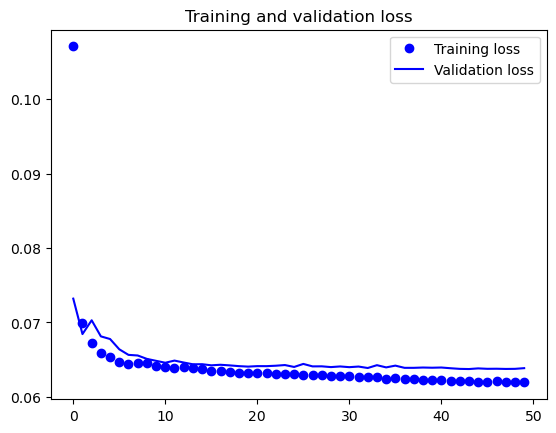

In [301]:
loss = autoencoder.history['loss']
val_loss = autoencoder.history['val_loss']
epochs = range(hp_epochs)
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

In [302]:
autoencoder_model.save_weights('checkpoints/ex9/autoencoder2_weights.weights.h5',
                               overwrite = True)

encoder_model = keras.Model(inputs = input_data, outputs = Encoder(input_data))
encoder_model.load_weights('checkpoints/ex9/autoencoder2_weights.weights.h5',
                           skip_mismatch = True)
encoder_model.compile(
  loss = hp_loss_fn,
  optimizer = hp_optimizer,
  metrics = hp_metrics,
)

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


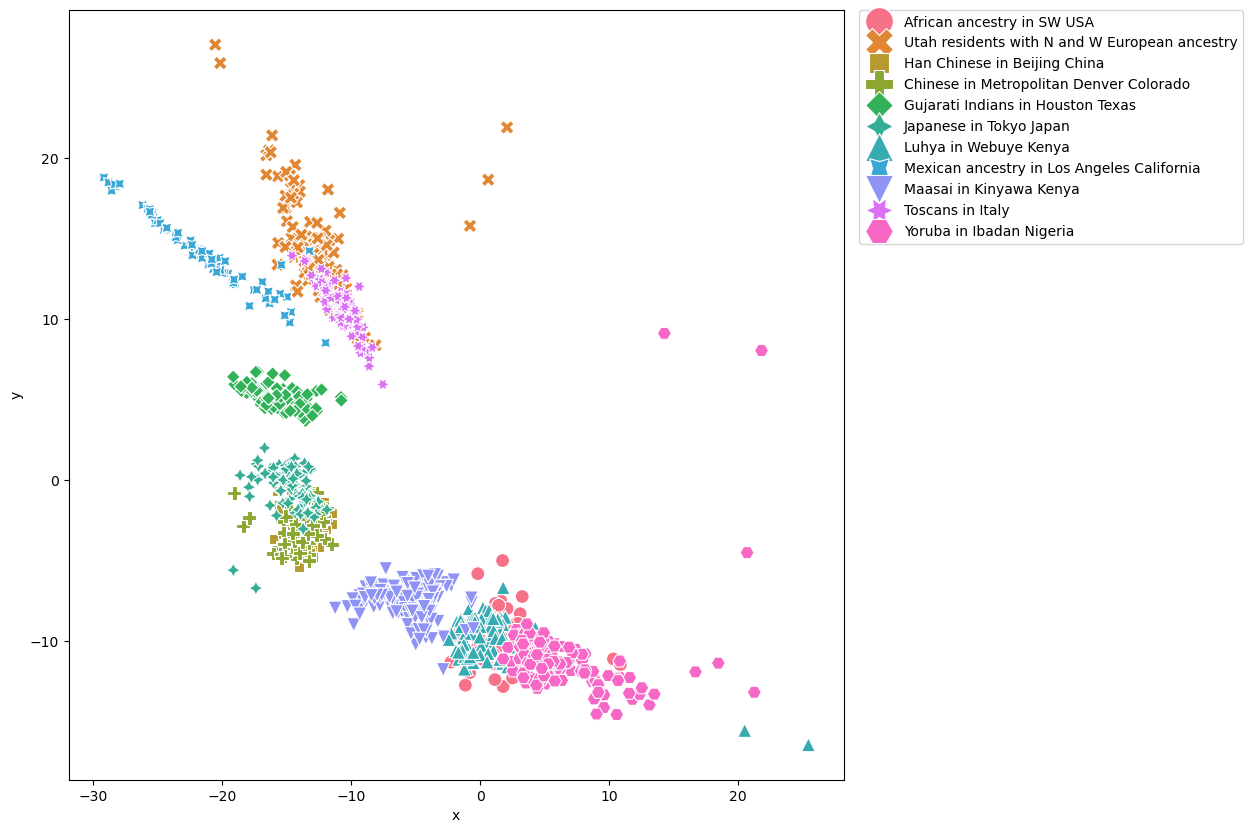

In [303]:
embeded_points = encoder_model.predict(geno_data.to_numpy())
# print(embeded_points)

x = embeded_points[:,0]
y = embeded_points[:,1]
pop = pheno2['population']
data = {'x':x, 'y':y, 'pop':pop}
plt.figure(figsize = (10,10))
sns.scatterplot(x='x', y='y', data=data, hue='pop', style='pop', s=100)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, markerscale=2)
plt.show()

The separation is now much better. Most of the populations are not overlapping anymore. There is still some groups, like the asiatic populations or some of the african populations, but some like the Gujarati indians are completely separated.

### Missing values

Let us check now the performance of the models when some values are missing. To that end, we add 1 to the original value of the genotype (and normalize again) and insert some 0 as missing values.

In [304]:
geno_data1 = (geno_data + 0.5) / 1.5

missing_fraction = 0.20
mask = np.random.rand(*geno_data1.shape) < missing_fraction
geno_data1 = geno_data1.mask(mask, 0)

geno_data1.head()

,rs416967,rs17013842,rs13052452,rs11049986,rs10994341,rs1504289,rs882529,rs3885937,rs537330,rs9372090,...,rs1558766,rs7818288,rs1051685,rs11223492,rs789492,rs6557516,rs7313246,rs317892,rs11937009,rs2806497
NA19919,1.000000,0.000000,0.333333,0.666667,0.666667,0.333333,0.000000,0.666667,0.000000,0.666667,...,0.000000,0.666667,0.333333,0.333333,0.000000,0.333333,0.666667,0.000000,0.666667,0.333333
NA19916,0.000000,0.333333,0.333333,0.666667,0.666667,0.333333,0.000000,0.000000,1.000000,0.666667,...,0.333333,0.333333,0.000000,0.333333,0.333333,0.666667,0.666667,0.666667,0.666667,0.333333
NA19835,0.333333,0.333333,0.000000,0.666667,0.333333,0.666667,0.333333,1.000000,1.000000,0.666667,...,0.000000,0.666667,0.333333,0.333333,0.333333,0.000000,1.000000,1.000000,0.333333,0.333333
NA20282,0.666667,0.666667,0.333333,0.000000,0.333333,0.333333,0.333333,0.333333,0.666667,0.666667,...,0.333333,0.000000,0.333333,0.333333,0.333333,0.000000,0.666667,0.000000,0.000000,0.333333
NA19703,0.333333,0.000000,0.333333,0.333333,0.666667,0.000000,0.333333,0.333333,0.333333,1.000000,...,0.333333,0.666667,0.666667,0.333333,0.000000,0.000000,0.666667,0.666667,0.000000,0.333333


In [305]:
# TASK Randomly split into the training and the validation set, so that 80 per-cent of individuals ends up in the training set.
train = geno_data1.sample(frac = 0.8, random_state = 42)
test = geno_data1.drop(train.index)
train = train.copy()
test = test.copy()
train.reset_index()
test.reset_index();

We will use the best autoencoder hyperparameters we found.

In [306]:
# TASK Specify the autoencoder model
train_tensor = train.to_numpy()

# TASK Hyperparameters
# use ReLu activations, ADAM optimizer and
# mean squared error as the loss function
hp_loss_fn = 'mse'
hp_act_fn = 'relu'
hp_optimizer = 'adam'
hp_metrics = ['mse','mae','mape']

input_data = keras.Input(shape = (train_tensor.shape[1],))

# TASK Define architecture of the encoder:
# the second layer should be a batch normalization
def Encoder(input):
  # Encoder
  layer1 = layers.Dense(units = 1500, activation = hp_act_fn, name='layer1')(input)
  layer2 = layers.BatchNormalization(name='layer2')(layer1)
  layer3 = layers.Dropout(rate = 0.025, name='layer3')(layer2)
  layer4 = layers.Dense(units = 250, activation = hp_act_fn, name='layer4')(layer3)
  layer5 = layers.Dropout(rate = 0.025, name='layer5')(layer4)
  layer6 = layers.Dense(units = 25, activation = hp_act_fn, name='layer6')(layer5)
  bottleneck = layers.Dense(units = 2, name='layer_bottleneck')(layer6)
  return(bottleneck)

# TASK Look at the encoder, complete the decoder function
def Decoder(bottleneck):
  # Decoder
  layer7 = layers.Dense(units = 25, activation = hp_act_fn, name='layer7')(bottleneck)
  layer8 = layers.Dropout(rate = 0.025, name='layer8')(layer7)
  layer9 = layers.Dense(units = 250, activation = hp_act_fn, name='layer9')(layer8)
  layer10 = layers.Dropout(rate = 0.025, name='layer10') (layer9)
  layer11 = layers.Dense(units = 1500, activation = hp_act_fn, name='layer11')(layer10)
  layer12 = layers.Dense(units = train_tensor.shape[1], activation = 'sigmoid', name='layer_output')(layer11)
  return(layer12)

def Autoencoder(input):
  enc = Encoder(input)
  autoenc = Decoder(enc)
  return(autoenc)

autoencoder_model = keras.Model(inputs = input_data, outputs = Autoencoder(input_data))
autoencoder_model.compile(
  loss = hp_loss_fn,
  optimizer = hp_optimizer,
  metrics = hp_metrics
)

# TASK Visualise the created architecture and summarise its parameters
autoencoder_model.summary()

Model: "functional_61"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_38 (InputLayer)     │ (None, 5000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer1 (Dense)                  │ (None, 1500)           │     7,501,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (BatchNormalization)     │ (None, 1500)           │         6,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer3 (Dropout)                │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer4 (Dense)                  │ (None, 250)            │       375,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer5 (Dropout)                │ (None, 250)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer6 (Dense)                  │ (None, 25)             │         6,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_bottleneck (Dense)        │ (None, 2)              │            52 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer7 (Dense)                  │ (None, 25)             │            75 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer8 (Dropout)                │ (None, 25)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer9 (Dense)                  │ (None, 250)            │         6,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer10 (Dropout)               │ (None, 250)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer11 (Dense)                 │ (None, 1500)           │       376,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_output (Dense)            │ (None, 5000)           │     7,505,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,777,152 (60.19 MB)

 Trainable params: 15,774,152 (60.17 MB)

 Non-trainable params: 3,000 (11.72 KB)

In [307]:
# TASK Set hyperparameters for model fitting
# Begin by training for 30 epochs, with mini-batch of 256 and validation set
# having 20 per-cent of examples
hp_epochs = 50
hp_batch_size = 32
hp_val_split = 0.2

autoencoder = autoencoder_model.fit(x = train_tensor,
                      y = train_tensor,
                      epochs = hp_epochs,
                      batch_size = hp_batch_size,
                      shuffle = True,
                      validation_split = hp_val_split,
                      )

Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.0679 - mae: 0.2086 - mape: 82575744.0000 - mse: 0.0679 - val_loss: 0.0646 - val_mae: 0.2048 - val_mape: 62665652.0000 - val_mse: 0.0646
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0628 - mae: 0.1934 - mape: 75352408.0000 - mse: 0.0628 - val_loss: 0.0600 - val_mae: 0.1816 - val_mape: 75272944.0000 - val_mse: 0.0600
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0602 - mae: 0.1844 - mape: 74594088.0000 - mse: 0.0602 - val_loss: 0.0603 - val_mae: 0.1853 - val_mape: 72137136.0000 - val_mse: 0.0603
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0591 - mae: 0.1811 - mape: 73811376.0000 - mse: 0.0591 - val_loss: 0.0604 - val_mae: 0.1836 - val_mape: 74871568.0000 - val_mse: 0.0604
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0589 - mae: 0.1808 - mape: 73627496.0000 - mse: 0.0589 - val_loss: 0.0612 - val_mae: 0.1871 - val_mape: 73520728.0000 - val_mse: 0.0612
Epoch 6/50
24/2

In [308]:
autoencoder_model.save_weights('checkpoints/ex9/autoencoder_missing_weights.weights.h5',
                               overwrite = True)

encoder_model = keras.Model(inputs = input_data, outputs = Encoder(input_data))
encoder_model.load_weights('checkpoints/ex9/autoencoder_missing_weights.weights.h5',
                           skip_mismatch = True)
encoder_model.compile(
  loss = hp_loss_fn,
  optimizer = hp_optimizer,
  metrics = hp_metrics,
)

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


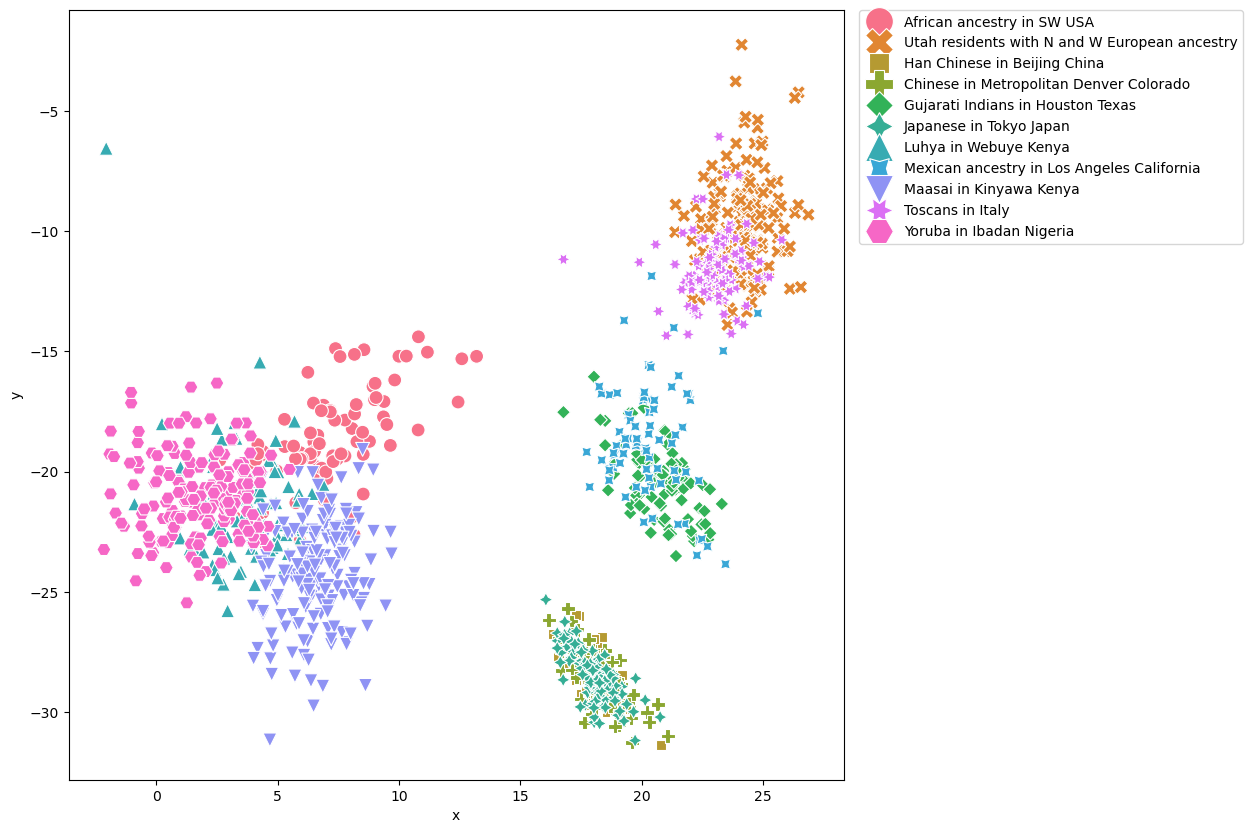

In [309]:
embeded_points = encoder_model.predict(geno_data.to_numpy())
# print(embeded_points)

x = embeded_points[:,0]
y = embeded_points[:,1]
pop = pheno2['population']
data = {'x':x, 'y':y, 'pop':pop}
plt.figure(figsize = (10,10))
sns.scatterplot(x='x', y='y', data=data, hue='pop', style='pop', s=100)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, markerscale=2)
plt.show()

Even with a 20% of missing values, the autoencoder is able to distinguish the 4 main groups defined before. We lost a bit of performance due to the missing values, but the result is still quite good. PCA and MDS do not work that well with missing data.